<a href="https://colab.research.google.com/github/sekhahelina/ML_tasks/blob/main/Module2/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



https://github.com/sekhahelina/ML_tasks/blob/main/Module2/process_bank_churn.py

In [9]:
from process_bank_churn import preprocess_data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

### Imports

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import seaborn as sns

In [39]:
raw_df = pd.read_csv("/content/drive/MyDrive/dataframes/Bank/train.csv", index_col=0)
data = preprocess_data(raw_df, False)

In [80]:
data[:5]

(       CreditScore   Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 id                                                                      
 7180         682.0  30.0     1.0  131394.56            1.0        1.0   
 10393        684.0  39.0     2.0  178058.06            1.0        1.0   
 80           705.0  35.0     6.0  116320.68            2.0        1.0   
 3365         669.0  58.0     0.0       0.00            2.0        0.0   
 12236        707.0  21.0     3.0       0.00            2.0        1.0   
 ...            ...   ...     ...        ...            ...        ...   
 9493         633.0  33.0     4.0       0.00            2.0        0.0   
 8463         673.0  40.0     1.0       0.00            1.0        1.0   
 8143         621.0  29.0     8.0       0.00            2.0        1.0   
 11512        590.0  42.0     7.0       0.00            2.0        0.0   
 9360         545.0  27.0     2.0       0.00            2.0        1.0   
 
        IsActiveMember  EstimatedSal

In [54]:
(
    X_train,
    train_targets,
    X_val,
    val_targets,
    input_cols,
    scaler,
    encoder,
    numeric_imputer,
    categorical_imputer
) = preprocess_data(raw_df, False)

In [55]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, train_targets)
train_preds = tree_model.predict(X_train)


In [56]:
pd.value_counts(train_preds)

/tmp/ipykernel_728/1258350197.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_preds)


,count
0.0,9558
1.0,2442


In [57]:
accuracy_score(train_targets, train_preds)

1.0

In [83]:
def compute_auroc_and_build_roc(inputs, targets, name='', plot: bool = True):
  # Predict probabilities
  probs = tree_model.predict_proba(inputs)[:, 1]
  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, probs)
  # Compute AUROC
  roc_auc = auc(fpr, tpr)

  print(f'AUROC for {name}: {roc_auc:.2f}')

  if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(
            fpr,
            tpr,
            color='darkorange',
            lw=2,
            label=f'ROC curve (AUC = {roc_auc:.2f})'
        )
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve ({name})')
        plt.legend(loc='lower right')
        plt.show()

  return

AUROC for Training: 1.00


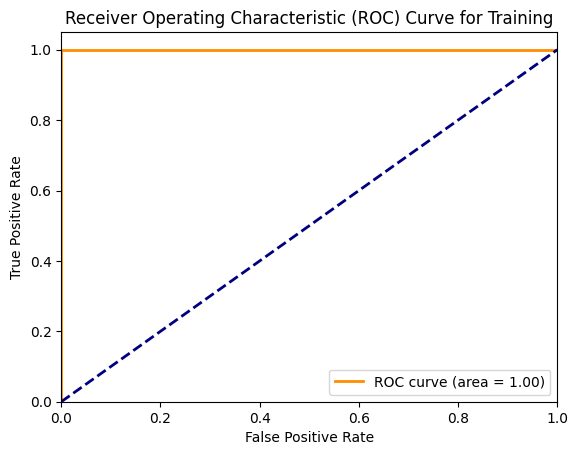

In [59]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')

AUROC for Validation: 0.77


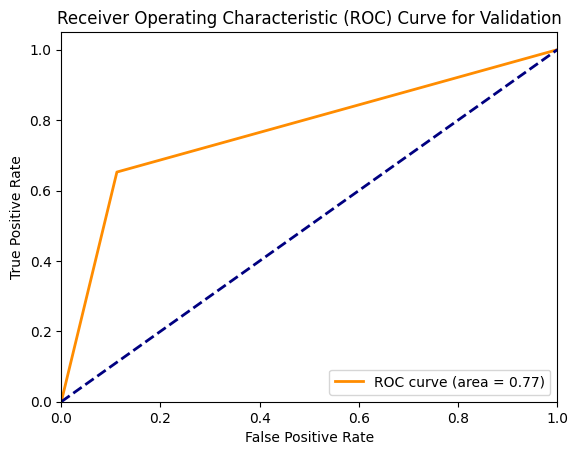

In [29]:
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [60]:
val_targets.value_counts() / len(val_targets)

,count
Exited,
0.0,0.796667
1.0,0.203333


Оцінивши результати моделі можна зробити висновок, що модель перенавчена, оскільки на тренувальних даних модель дає 100% точність. Після оцінки точності на валідаційних даних, бачимо що AUCROC = 71%. Крім того, це нижче за accuracy базової моделі, яка завжди прогнозує переважаючий клас = 0.79%. Отже, модель запам'ятала тренувальні дані, але погано узагальнює закономірності та демонструє низьку здатність до генералізації.

In [61]:
tree_model.tree_.max_depth

26

In [62]:
tree_model = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_model.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=2, random_state=42)

AUROC for Training: 0.84


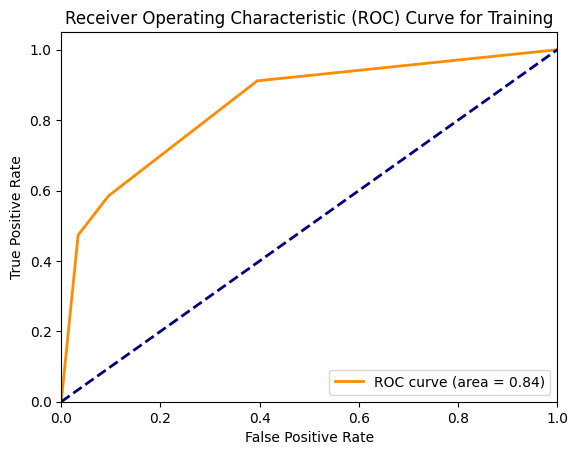

AUROC for Validation: 0.85


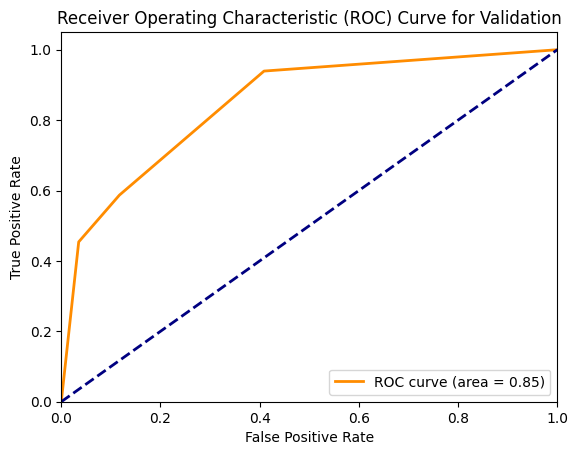

In [63]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

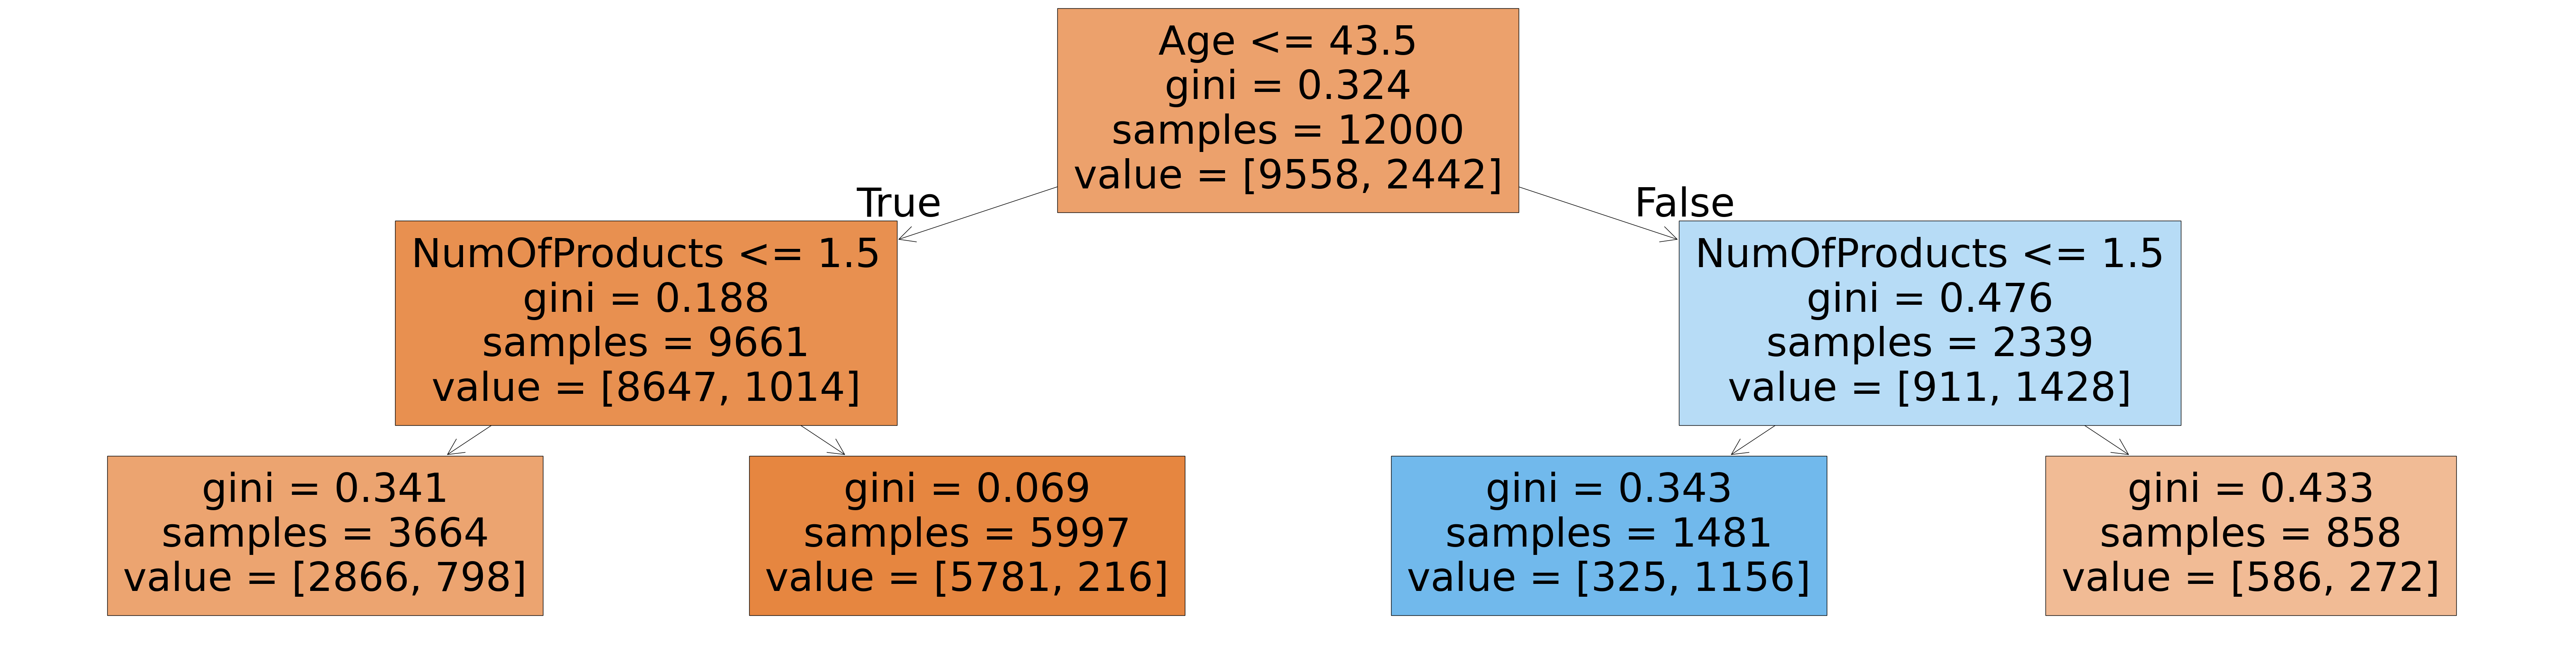

In [68]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(80,20))
plot_tree(tree_model, feature_names=X_train.columns, filled=True);

In [65]:
tree_text = export_text(tree_model, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 43.50
|   |--- NumOfProducts <= 1.50
|   |   |--- class: 0.0
|   |--- NumOfProducts >  1.50
|   |   |--- class: 0.0
|--- Age >  43.50
|   |--- NumOfProducts <= 1.50
|   |   |--- class: 1.0
|   |--- NumOfProducts >  1.50
|   |   |--- class: 0.0



In [70]:
tree_model.feature_importances_.round(2)

array([0.  , 0.71, 0.  , 0.  , 0.29, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  ])

Можемо зробити висновок, що найвпливовішими ознаками є Age та NumOfProducts

### Feature Importance

In [71]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree_model.feature_importances_
}).sort_values('importance', ascending=False)

In [74]:
importance_df

,feature,importance
1,Age,0.714962
4,NumOfProducts,0.285038
0,CreditScore,0.000000
2,Tenure,0.000000
3,Balance,0.000000
5,HasCrCard,0.000000
6,IsActiveMember,0.000000
7,EstimatedSalary,0.000000
8,Geography_France,0.000000
9,Geography_Germany,0.000000


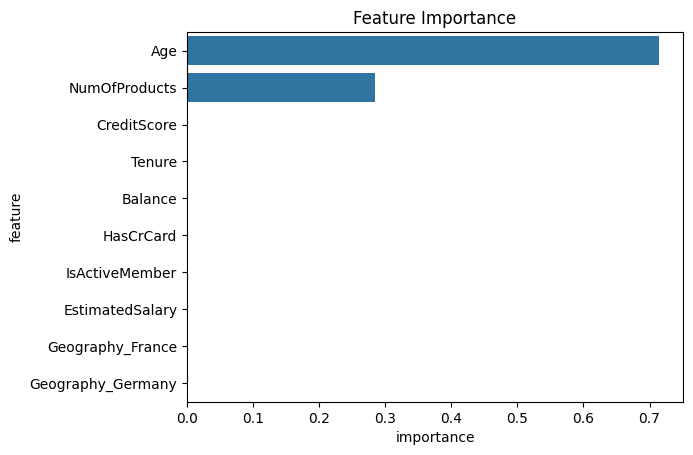

In [77]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

### **Завдання 3**.
Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [84]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, train_targets)

compute_auroc_and_build_roc(X_train, train_targets, 'Training', False)
compute_auroc_and_build_roc(X_val, val_targets, 'Validation', False)

AUROC for Training: 0.93
AUROC for Validation: 0.92


In [85]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, train_targets)

compute_auroc_and_build_roc(X_train, train_targets, 'Training', False)
compute_auroc_and_build_roc(X_val, val_targets, 'Validation', False)

AUROC for Training: 0.91
AUROC for Validation: 0.91


In [86]:
tree_model = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_model.fit(X_train, train_targets)

compute_auroc_and_build_roc(X_train, train_targets, 'Training', False)
compute_auroc_and_build_roc(X_val, val_targets, 'Validation', False)

AUROC for Training: 0.93
AUROC for Validation: 0.92


In [87]:
tree_model = DecisionTreeClassifier(max_depth=8, random_state=42)
tree_model.fit(X_train, train_targets)

compute_auroc_and_build_roc(X_train, train_targets, 'Training', False)
compute_auroc_and_build_roc(X_val, val_targets, 'Validation', False)

AUROC for Training: 0.95
AUROC for Validation: 0.90


In [88]:
tree_model = DecisionTreeClassifier(max_depth=7, random_state=42)
tree_model.fit(X_train, train_targets)

compute_auroc_and_build_roc(X_train, train_targets, 'Training', False)
compute_auroc_and_build_roc(X_val, val_targets, 'Validation', False)

AUROC for Training: 0.94
AUROC for Validation: 0.91


In [100]:
tree_model = DecisionTreeClassifier(max_depth=6, max_leaf_nodes=30, random_state=42)
tree_model.fit(X_train, train_targets)

compute_auroc_and_build_roc(X_train, train_targets, 'Training', False)
compute_auroc_and_build_roc(X_val, val_targets, 'Validation', False)

AUROC for Training: 0.93
AUROC for Validation: 0.92


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

### Функція для підбору глибини  дерева

In [104]:
def max_depth_roc_auc(md):
    tree_model = DecisionTreeClassifier(max_depth=md, random_state=42)
    tree_model.fit(X_train, train_targets)

    train_probs = tree_model.predict_proba(X_train)[:, 1]
    val_probs = tree_model.predict_proba(X_val)[:, 1]

    train_auc = roc_auc_score(train_targets, train_probs)
    val_auc = roc_auc_score(val_targets, val_probs)

    return {
        'Max Depth': md,
        'Training ROC-AUC': train_auc,
        'Validation ROC-AUC': val_auc
    }

In [117]:
depth_results = []

for md in range(1, 21):
    depth_results.append(max_depth_roc_auc(md))

depth_df = pd.DataFrame(depth_results)
depth_df.style.background_gradient(subset='Validation ROC-AUC', cmap='Blues')

,Max Depth,Training ROC-AUC,Validation ROC-AUC
0,1,0.744727,0.734865
1,2,0.842908,0.846496
2,3,0.897184,0.891146
3,4,0.911281,0.911264
4,5,0.925694,0.921927
5,6,0.933778,0.921111
6,7,0.941535,0.914449
7,8,0.949541,0.902790
8,9,0.959079,0.884709
9,10,0.969765,0.848436


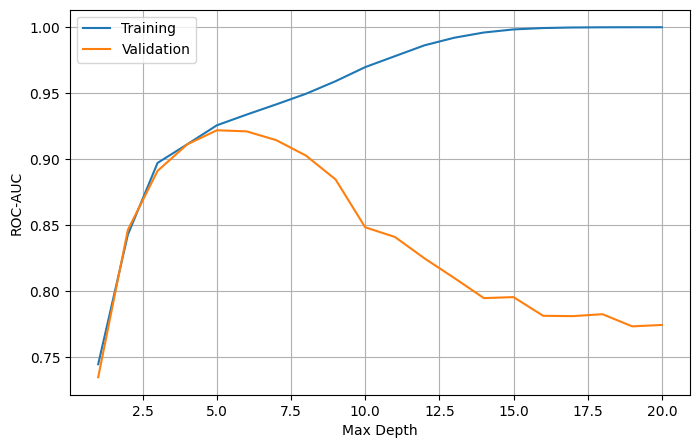

In [120]:
plt.figure(figsize=(8, 5))

plt.plot(depth_df["Max Depth"], depth_df["Training ROC-AUC"], label="Training")
plt.plot(depth_df["Max Depth"], depth_df["Validation ROC-AUC"], label="Validation")

plt.xlabel("Max Depth")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True)

plt.show()

На графіку чітко бачимо, що наша метрика починає зменшуватись на валідаційних даних після глибини 5, отже оптимальним варіантом буде дерево з глибиною 5.

### **Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [121]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=5, random_state=42)

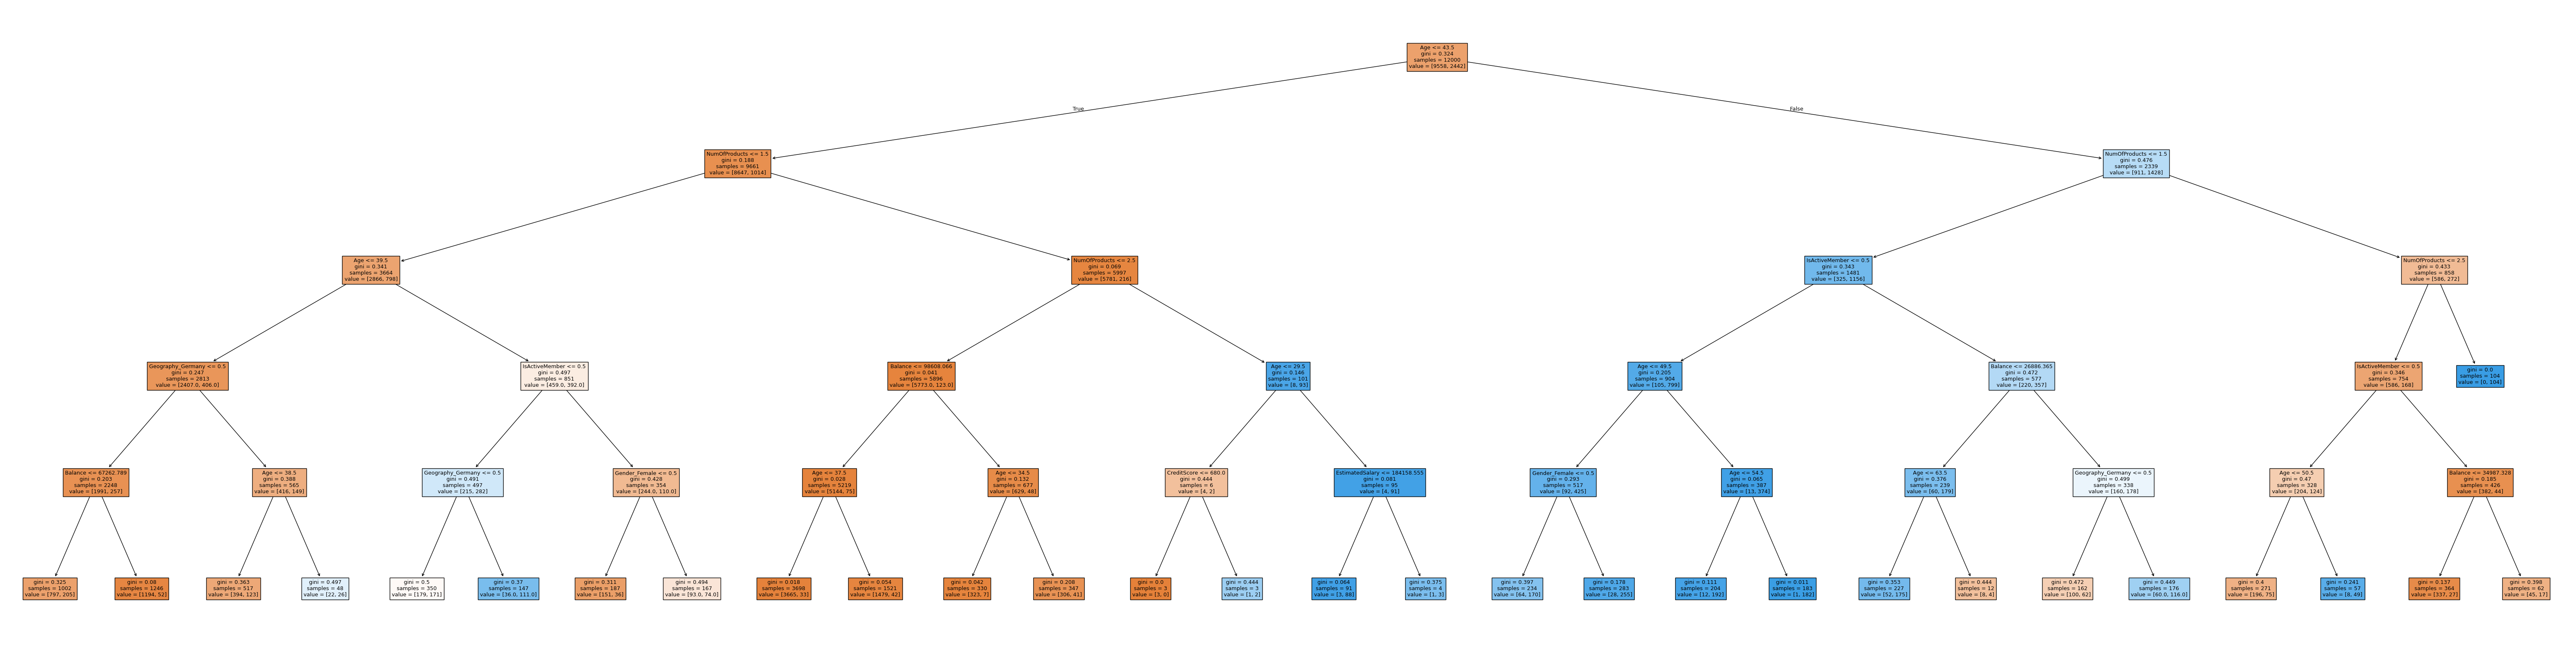

In [122]:
plt.figure(figsize=(80,20))
plot_tree(tree_model, feature_names=X_train.columns, filled=True);

In [125]:
from process_bank_churn import preprocess_new_data

In [127]:
test_raw_df = pd.read_csv('/content/drive/MyDrive/dataframes/Bank/test.csv')
test_data = preprocess_new_data(
    test_raw_df,
    input_cols,
    scaler,
    encoder,
    numeric_imputer,
    categorical_imputer,
    scale_numeric=False
)

In [128]:
test_data

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,584.0,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.0,1.0,0.0,0.0,1.0
1,551.0,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,1.0,0.0,0.0,0.0,1.0
2,706.0,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,1.0,0.0,0.0,0.0,1.0
3,717.0,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.0,0.0,1.0,0.0,1.0
4,592.0,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,639.0,38.0,10.0,0.00,2.0,1.0,1.0,49637.65,0.0,0.0,1.0,0.0,1.0
9996,678.0,39.0,9.0,0.00,2.0,1.0,1.0,142513.50,0.0,0.0,1.0,0.0,1.0
9997,774.0,30.0,9.0,0.00,2.0,1.0,0.0,4861.72,1.0,0.0,0.0,0.0,1.0
9998,595.0,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09,1.0,0.0,0.0,0.0,1.0


In [129]:
test_probs = tree_model.predict_proba(test_data)[:, 1]

In [130]:
test_probs

array([0.23791103, 0.02761341, 0.02761341, ..., 0.00892374, 0.04173355,
       0.20459082])

In [131]:
submission_decision_tree = pd.read_csv('/content/drive/MyDrive/dataframes/Bank/sample_submission.csv')
submission_decision_tree['Exited'] = test_probs
submission_decision_tree.head()

,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.770925
4,15004,0.027613


In [132]:
submission_decision_tree.to_csv('submission_decision_tree.csv', index=False)

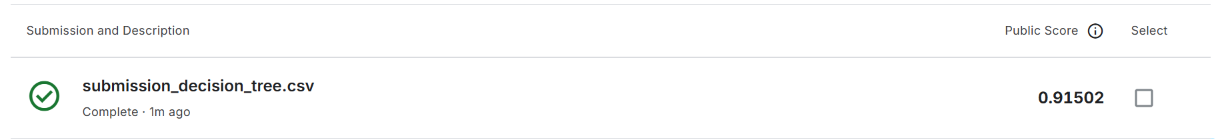

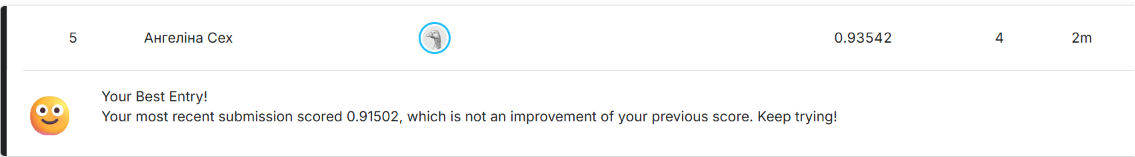